In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.decomposition import PCA

In [2]:
DATA_PATH = "./dataset/training_data.json"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "training_data.json"

with open(DATA_PATH, "r") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
display(df.head())

,src_port,dst_port,packet_size,duration_ms,protocol
0,443,17035,981,190,TCP
1,80,16694,893,128,UDP
2,80,23863,417,56,TCP
3,22,44311,1490,160,TCP
4,443,52777,372,308,UDP


In [ ]:
df_encoded = pd.get_dummies(df, columns=["protocol"], drop_first=True)

X = df_encoded[
    [
        "src_port",
        "dst_port",
        "packet_size",
        "duration_ms",
        "protocol_UDP"
    ]
]

print("Preprocessed features shape:", X.shape)
display(X.head())

Preprocessed features shape: (1000, 5)


,src_port,dst_port,packet_size,duration_ms,protocol_UDP
0,443,17035,981,190,False
1,80,16694,893,128,True
2,80,23863,417,56,False
3,22,44311,1490,160,False
4,443,52777,372,308,True


In [4]:
MODEL_PATH = "anomaly_model.joblib"

try:
    model = joblib.load(MODEL_PATH)
    predictions = model.predict(X)
    
    df['anomaly_status'] = np.where(predictions == 1, 'Normal', 'Anomaly')
    
    print("Predictions calculated successfully.")
    print(df['anomaly_status'].value_counts())
    
except FileNotFoundError:
    print(f"Error: '{MODEL_PATH}' not found. Please train the baseline model first.")

Predictions calculated successfully.
anomaly_status
Normal     900
Anomaly    100
Name: count, dtype: int64


In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df_plot = pd.DataFrame(X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_plot['Prediction'] = df['anomaly_status']

print("PCA dimensionality reduction complete.")
display(df_plot.head())

PCA dimensionality reduction complete.


,Principal Component 1,Principal Component 2,Prediction
0,-16388.448504,-1864.767308,Normal
1,-16727.808901,-2229.194400,Normal
2,-9558.531028,-2198.329165,Normal
3,10888.764653,-2169.026491,Normal
4,19353.582711,-1711.438382,Normal


Visualization plot saved successfully as 'anomaly_visualization.png'


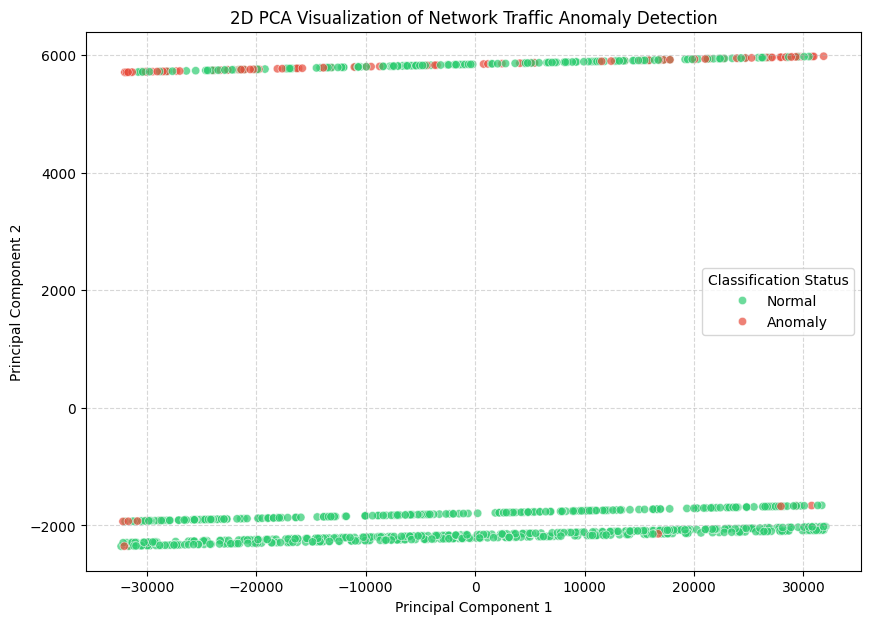

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='Prediction', 
    palette={'Normal': '#2ecc71', 'Anomaly': '#e74c3c'},
    alpha=0.7,
    data=df_plot
)

plt.title('2D PCA Visualization of Network Traffic Anomaly Detection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Classification Status')
plt.grid(True, linestyle='--', alpha=0.5)
output_image = "anomaly_visualization.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Visualization plot saved successfully as '{output_image}'")

plt.show()